<center><u><H1>AdaBoost</H1></u></center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
%matplotlib inline

In [2]:
iris = load_iris()
X=iris.data
y=iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=2018)

## Decision Tree as weak learner:

In [4]:
dt = DecisionTreeClassifier(criterion='entropy',max_depth=1)

In [5]:
dt = dt.fit(X_train, y_train)

In [6]:
dt_pred = dt.predict(X_test)

## Metrics of weak learner:

In [7]:
print(accuracy_score(y_test,dt_pred))

0.6444444444444445


In [8]:
print(confusion_matrix(y_test,dt_pred))

[[18  0  0]
 [ 0 11  0]
 [ 0 16  0]]


In [9]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.41      1.00      0.58        11
           2       0.00      0.00      0.00        16

    accuracy                           0.64        45
   macro avg       0.47      0.67      0.53        45
weighted avg       0.50      0.64      0.54        45



c:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## AdaBoost:

In [10]:
from sklearn.ensemble import AdaBoostClassifier

In [12]:
ada = AdaBoostClassifier(estimator=dt, n_estimators=100, learning_rate=0.5, random_state=2018)

In [13]:
ada = ada.fit(X_train, y_train)

In [14]:
ada_pred = ada.predict(X_test)

## Metrics of AdaBoost

In [15]:
print(accuracy_score(y_test,ada_pred))

0.9333333333333333


In [16]:
print(confusion_matrix(y_test,ada_pred))

[[18  0  0]
 [ 0 11  0]
 [ 0  3 13]]


In [17]:
print(classification_report(y_test,ada_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.79      1.00      0.88        11
           2       1.00      0.81      0.90        16

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.95      0.93      0.93        45



## Plotting models:

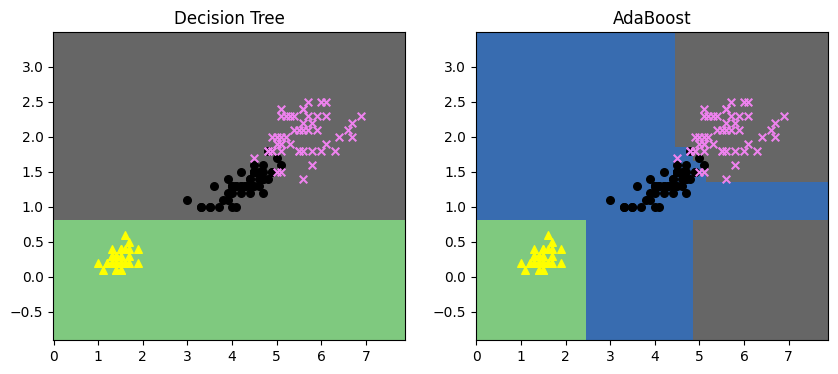

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
res = 0.02
X2 = X[:,[2,3]]

x1min, x1max = X2[:,0].min() -1, X2[:,0].max() + 1
x2min, x2max = X2[:,1].min() -1, X2[:,1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1min,x1max,res),np.arange(x2min,x2max,res))

for clf, ax, title in zip([dt, ada], axs, ['Decision Tree','AdaBoost']):
    clf.fit(X2, y)
    output = clf.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    output = output.reshape(xx1.shape)
    ax.pcolormesh(xx1,xx2, output, cmap=plt.cm.Accent)
    ax.scatter(X2[y==0, 0], X2[y==0, 1], s=30, color='yellow', marker='^')
    ax.scatter(X2[y==1, 0], X2[y==1, 1], s=30, color='black', marker='o')
    ax.scatter(X2[y==2, 0], X2[y==2, 1], s=30, color='violet', marker='x')
    ax.set_title(title)  

## Reference:
http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html